# **Mineral Prospectivity Project**
## 03 feature engineering

goals:\
-create spatial grid\
-sample data into grid

### Part 1. import packages and document grid details

a. grid information:\
-500 x 500 m resolution\
-extent: state of Idaho

In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import box

aoi = gpd.read_file('/Users/adbyerly/prospectivity_model/data/raw/maps/idaho_outline.gpkg')
print(aoi.crs)
# print(aoi.geometry.iloc[0])
# print(aoi.total_bounds)

In [ ]:
# create grid
aoi = aoi.to_crs("EPSG:32611")     # convert to UTM Zone 11N (not perfect, but a good compromise for all of Idaho)

xmin, ymin, xmax, ymax = aoi.total_bounds
cell_size = 1000
# print(aoi.geometry.iloc[0])
# print(aoi.total_bounds)


In [44]:
grid_cells = [
    box(x, y, x + cell_size, y + cell_size)
    for x in np.arange(xmin, xmax, cell_size)
    for y in np.arange(ymin, ymax, cell_size)
]

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=target_crs)

grid = grid[grid.centroid.within(aoi.unary_union)]
grid["cell_id"] = range(len(grid))


/var/folders/5k/44z6_qv57sz8v3pzftxvfn4m0000gn/T/ipykernel_1219/3310355438.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid = grid[grid.centroid.within(aoi.unary_union)]


True
EPSG:32611
216626
(480643.93024405686, 4913552.880543355, 481643.93024405686, 4914552.880543355)
1000.0
1000.0


<Axes: >

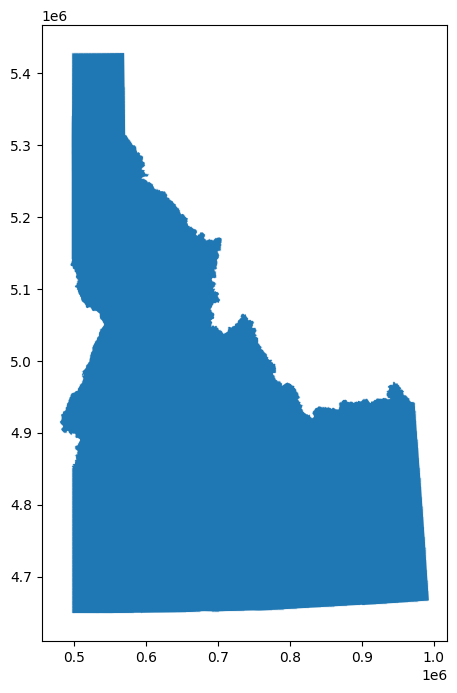

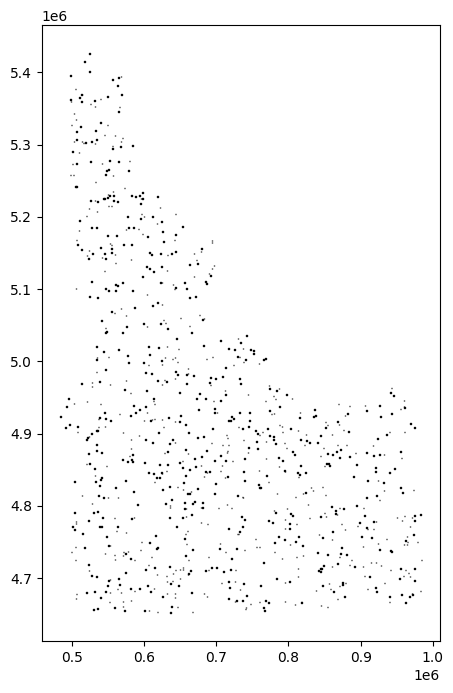

In [45]:
# grid QC
print(grid["cell_id"].is_unique)
print(grid.crs)
print(len(grid))
cell = grid.geometry.iloc[0]

# check cell dimensions
print(cell.bounds)
minx, miny, maxx, maxy = cell.bounds
print(maxx - minx)
print(maxy - miny)

# state-wide grid is too fine to see
ax = aoi.plot(figsize=(8, 8))
grid.boundary.plot(ax=ax, linewidth=0.1)

# plot a random subset of cells
grid.sample(1000).plot(
    facecolor="none",
    edgecolor="black",
    figsize=(8, 8))